## Which circuit(s) are the most difficult to finish?

To measure difficulty, we will take a track's median lap time and scale that by the track length to account for different circuit lengths which is the average rate.
<br>
We will also be looking at races from 2014 - 2016. This is to account for improvements in racing technology -- for example, race cars in 2008 would differ from cars in 2015 which would make lap times drastically different -- and different lap lengths. 2014–2016 is an ideal window for analyzing trends because car architecture, engine philosophy, and tire characteristics remained consistent without the confounding effects of major regulation resets.
<br>



##### Import packages

In [6]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

##### Read in csv files

In [64]:
races = pd.read_csv('1-Formula_One/races.csv')
circuits = pd.read_csv('1-Formula_One/circuits.csv')
df_time = pd.read_csv('1-Formula_One/lap_times.csv')
df_length = pd.read_csv('1-Formula_One/circuit_length.csv')

### Getting track lengths

Since the F1 datasets don't include any data on track length, we will need to append the track length data ourselves.
<br>
First, we will filter for races from 2014 to 2016 for our analysis. Then we will use the `raceId` column to filter for those races from our time dataframe. Finally, we will create a new dataframe by merging the time with a track length dataframe

In [65]:
races_1416 = races.query('2014 <= year <= 2016')

In [66]:
# get race IDs from 2014 - 2016 and 
unique_raceID = races_1416['raceId'].unique()

df_time1416 = df_time.query('raceId in @unique_raceID')

# map circuit to race
race_lookup = races.set_index('raceId')['circuitId']
df_time1416['circuitId'] = df_time1416['raceId'].map(race_lookup)

# get average lap time in milliseconds per circuit
df_average = df_time1416.groupby('circuitId')['milliseconds'].mean().reset_index()
#get average track length from 2014-2016 per circuit
df_length_avg = (df_length.groupby('circuitId')['circuit_length'].mean().reset_index())
df_avg = pd.merge(df_average, df_length_avg, on='circuitId', how='left')

#merge track length and average lap time
df_length = df_length[['circuitId','circuit_name']].drop_duplicates()
df_final = pd.merge(df_avg,df_length,
                     on='circuitId',
                     how='left')

# rearrange columns and rename to make the dataframe look nicer
df_final = df_final[['circuitId','circuit_name','milliseconds','circuit_length']]
df_final = df_final.rename(columns = {'circuit_length' : 'km'})
display(df_final)

C:\Users\aliso\AppData\Local\Temp\ipykernel_34948\2642631559.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_time1416['circuitId'] = df_time1416['raceId'].map(race_lookup)


,circuitId,circuit_name,milliseconds,km
0,1,Albert Park Grand Prix Circuit,105309.806899,5.303000
1,2,Sepang International Circuit,108792.127279,5.543000
2,3,Bahrain International Circuit,102922.829292,5.412000
3,4,Circuit de Barcelona-Catalunya,94071.382069,4.655000
4,6,Circuit de Monaco,88766.598623,3.338000
5,7,Circuit Gilles Villeneuve,81948.840299,4.361000
6,9,Silverstone Circuit,135649.708924,5.891000
7,10,Hockenheimring,84115.034850,4.574000
8,11,Hungaroring,93015.229970,4.381000
9,13,Circuit de Spa-Francorchamps,126613.017447,7.004000


### Determining the most difficult tracks

In [68]:
# find ms/km for each track
df_final['ms_per_km'] = df_final['milliseconds']/df_final['km']
df_final_sorted = df_final.sort_values(by='ms_per_km',ascending=False)

display(df_final_sorted)

,circuitId,circuit_name,milliseconds,km,ms_per_km
4,6,Circuit de Monaco,88766.598623,3.338000,26592.749737
13,18,Autódromo José Carlos Pace,103386.212208,4.309000,23993.087075
11,15,Marina Bay Street Circuit,119337.510664,5.063667,23567.410440
6,9,Silverstone Circuit,135649.708924,5.891000,23026.601413
8,11,Hungaroring,93015.229970,4.381000,21231.506499
17,69,Circuit of the Americas,111773.501626,5.513000,20274.533217
3,4,Circuit de Barcelona-Catalunya,94071.382069,4.655000,20208.674988
16,32,Autódromo Hermanos Rodríguez,86788.720438,4.304000,20164.665529
14,22,Suzuka Circuit,116992.621700,5.807000,20146.826537
0,1,Albert Park Grand Prix Circuit,105309.806899,5.303000,19858.534207


Text(0.5, 0, 'Circuit')

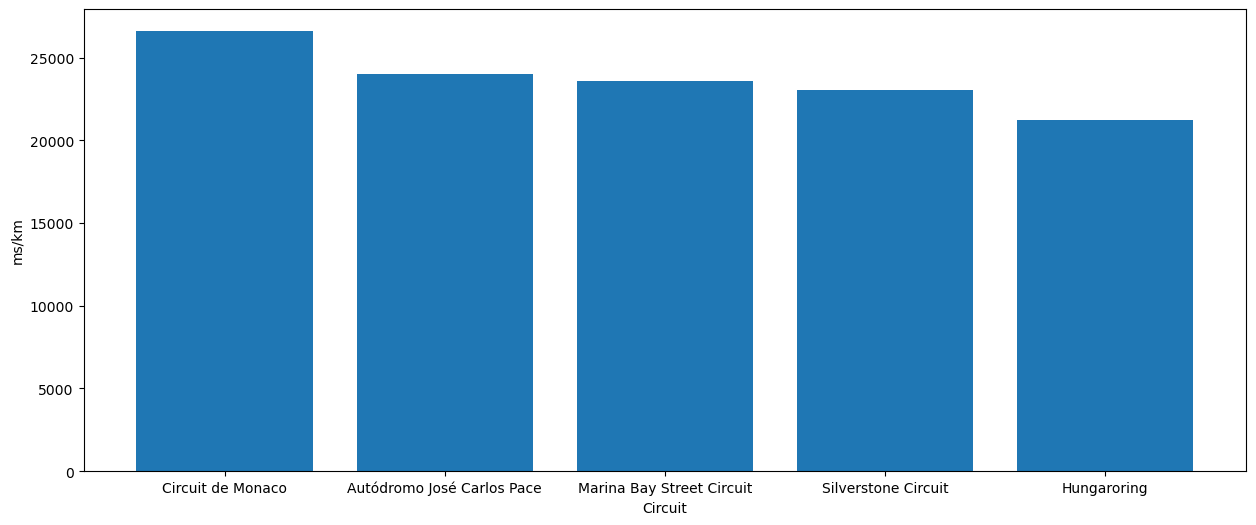

In [79]:
# plot
plt.figure(figsize=(15,6))
plt.bar("circuit_name","ms_per_km", data=df_final_sorted.head(5))
plt.ylabel('ms/km')
plt.xlabel('Circuit')


### Supplement: Creating the track length csv

In [8]:
df_racecircuit = races_1416[['raceId','year','circuitId','name']]

df_racecircuit

#create column of circuit name from circuit df
circuit_map = circuits.set_index("circuitId")["name"]
df_racecircuit["circuit_name"] = df_racecircuit["circuitId"].map(circuit_map)

df_racecircuit

df_racecircuit.to_csv('circuit_length.csv',index=False)

C:\Users\aliso\AppData\Local\Temp\ipykernel_34948\677708963.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_racecircuit["circuit_name"] = df_racecircuit["circuitId"].map(circuit_map)


After exporting the empty csv, circuit lengths in km were added in manually in Excel. Track data came from the Wikipedia articles linked in `circuits.csv`